In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

# Set seeds
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("\n STABLE TRANSFER LEARNING WITH MOBILENETV2")

plt.style.use('seaborn-v0_8-darkgrid')


TensorFlow version: 2.15.0

 STABLE TRANSFER LEARNING WITH MOBILENETV2


In [3]:
# Configuration with Windows paths
CONFIG = {
    'data_dir': 'C:\Python\ML Intro\Projects\Medical Image Classification\data\chest_xray',
    'models_dir': 'C:\Python\ML Intro\Projects\Medical Image Classification\models',
    'results_dir': 'C:\Python/ML Intro/Projects/Medical Image Classification/results',
    'img_size': (224, 224),
    'batch_size': 32,
    'epochs': 25,
    'initial_lr': 0.001,
    'dropout': 0.5,
}

# Create directories if they don't exist
Path(CONFIG['models_dir']).mkdir(parents=True, exist_ok=True)
Path(CONFIG['results_dir']).mkdir(parents=True, exist_ok=True)
Path(CONFIG['results_dir'], 'plots').mkdir(parents=True, exist_ok=True)
Path(CONFIG['results_dir'], 'metrics').mkdir(parents=True, exist_ok=True)

print(" Configuration:")
for key, value in CONFIG.items():
    print(f"   {key}: {value}")

 Configuration:
   data_dir: C:\Python\ML Intro\Projects\Medical Image Classification\data\chest_xray
   models_dir: C:\Python\ML Intro\Projects\Medical Image Classification\models
   results_dir: C:\Python/ML Intro/Projects/Medical Image Classification/results
   img_size: (224, 224)
   batch_size: 32
   epochs: 25
   initial_lr: 0.001
   dropout: 0.5


In [4]:
# Data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

# Define paths
train_dir = Path(CONFIG['data_dir']) / 'train'
val_dir = Path(CONFIG['data_dir']) / 'val'
test_dir = Path(CONFIG['data_dir']) / 'test'

# Create generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=CONFIG['img_size'],
    batch_size=CONFIG['batch_size'],
    class_mode='binary',
    shuffle=True,
    seed=42
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=CONFIG['img_size'],
    batch_size=CONFIG['batch_size'],
    class_mode='binary',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=CONFIG['img_size'],
    batch_size=CONFIG['batch_size'],
    class_mode='binary',
    shuffle=False
)

print("\n Data Loaded:")
print(f"   Train: {train_generator.samples}")
print(f"   Val: {val_generator.samples}")
print(f"   Test: {test_generator.samples}")
print(f"   Class indices: {train_generator.class_indices}")

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.

 Data Loaded:
   Train: 5216
   Val: 16
   Test: 624
   Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


In [5]:
# Check if validation set is too small
if val_generator.samples < 100:
    print(f"\n WARNING: Validation set very small ({val_generator.samples} samples)")
    print("   Creating validation split from training data instead...")
    
    # Use training data for validation split
    train_datagen_split = ImageDataGenerator(
        rescale=1./255,
        rotation_range=15,
        horizontal_flip=True,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.1,
        validation_split=0.15  # Use 15% for validation
    )
    
    train_generator = train_datagen_split.flow_from_directory(
        train_dir,
        target_size=CONFIG['img_size'],
        batch_size=CONFIG['batch_size'],
        class_mode='binary',
        subset='training',
        shuffle=True,
        seed=42
    )
    
    val_generator = train_datagen_split.flow_from_directory(
        train_dir,
        target_size=CONFIG['img_size'],
        batch_size=CONFIG['batch_size'],
        class_mode='binary',
        subset='validation',
        shuffle=False,
        seed=42
    )
    
    print(f"New Train: {train_generator.samples}")
    print(f"New Val: {val_generator.samples}")
else:
    print(f"Validation set size is adequate ({val_generator.samples} samples)")


   Creating validation split from training data instead...
Found 4434 images belonging to 2 classes.
Found 782 images belonging to 2 classes.
New Train: 4434
New Val: 782


In [6]:
print("\n  Building model with MobileNetV2...")

# Load base model
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze base initially
base_model.trainable = False

# Build model using Functional API
inputs = keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)  # Set training=False for batch norm
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(CONFIG['dropout'])(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(CONFIG['dropout'])(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = keras.Model(inputs, outputs, name='mobilenet_transfer')

print(f" Model created")
print(f"   Total parameters: {model.count_params():,}")
print(f"   Base model frozen: {not base_model.trainable}")

model.summary()


  Building model with MobileNetV2...


 Model created
   Total parameters: 2,422,081
   Base model frozen: True
Model: "mobilenet_transfer"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 mobilenetv2_1.00_224 (Func  (None, 7, 7, 1280)        2257984   
 tional)                                                         
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dropout (Dropout)           (None, 1280)              0         
                                                                 
 dense (Dense)               (None, 128)               163968    
 

In [7]:
# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(CONFIG['initial_lr']),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='auc')
    ]
)

print(" Model compiled successfully")
print(f"   Optimizer: Adam")
print(f"   Learning rate: {CONFIG['initial_lr']}")
print(f"   Loss: Binary Crossentropy")
print(f"   Metrics: Accuracy, Precision, Recall, AUC")

 Model compiled successfully
   Optimizer: Adam
   Learning rate: 0.001
   Loss: Binary Crossentropy
   Metrics: Accuracy, Precision, Recall, AUC


In [8]:
# Calculate class weights
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

# CRITICAL: Cap class weights to prevent over-emphasis
class_weights = np.clip(class_weights, 0.5, 2.0)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}

print("\n  Balanced Class Weights (capped 0.5-2.0):")
print(f"   Class 0 (NORMAL): {class_weight_dict[0]:.2f}")
print(f"   Class 1 (PNEUMONIA): {class_weight_dict[1]:.2f}")
print("\n Weights are capped to prevent model from over-focusing on minority class")


  Balanced Class Weights (capped 0.5-2.0):
   Class 0 (NORMAL): 1.94
   Class 1 (PNEUMONIA): 0.67

 Weights are capped to prevent model from over-focusing on minority class


In [9]:
# Define file paths
model_save_path = str(Path(CONFIG['models_dir']) / 'mobilenet_best.h5')

# Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_auc',
        patience=8,
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-6,  # Don't go too low
        verbose=1
    ),
    ModelCheckpoint(
        filepath=model_save_path,
        monitor='val_auc',
        mode='max',
        save_best_only=True,
        verbose=1
    )
]

print(" Callbacks configured:")
print("   1. Early Stopping (patience=8, monitor=val_auc)")
print("   2. Reduce LR on Plateau (factor=0.5, patience=4, min_lr=1e-6)")
print(f"   3. Model Checkpoint (save to: {model_save_path})")

 Callbacks configured:
   1. Early Stopping (patience=8, monitor=val_auc)
   2. Reduce LR on Plateau (factor=0.5, patience=4, min_lr=1e-6)
   3. Model Checkpoint (save to: C:\Python\ML Intro\Projects\Medical Image Classification\models\mobilenet_best.h5)


In [10]:
print("\n" + "="*70)
print(" TRAINING MOBILENET TRANSFER MODEL")
print("="*70)

# Train
history = model.fit(
    train_generator,
    epochs=CONFIG['epochs'],
    validation_data=val_generator,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

print("\n Training complete!")

# Training summary
print(f"\n Training Summary:")
print(f"   Epochs trained: {len(history.history['loss'])}")
print(f"   Best Val Accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"   Best Val AUC: {max(history.history['val_auc']):.4f}")
print(f"   Final LR: {history.history['lr'][-1]:.2e}")

# Check if model is stuck
final_val_auc = history.history['val_auc'][-1]
if final_val_auc < 0.70:
    print("\n  WARNING: Validation AUC is low. Model may not be learning well.")
else:
    print(f"\n Validation AUC looks good: {final_val_auc:.4f}")


 TRAINING MOBILENET TRANSFER MODEL
Epoch 1/25


139/139 [==============================] - ETA: 0s - loss: 0.3316 - accuracy: 0.8541 - precision: 0.9470 - recall: 0.8512 - auc: 0.9332
Epoch 1: val_auc improved from -inf to 0.97637, saving model to C:\Python\ML Intro\Projects\Medical Image Classification\models\mobilenet_best.h5
139/139 [==============================] - 139s 988ms/step - loss: 0.3316 - accuracy: 0.8541 - precision: 0.9470 - recall: 0.8512 - auc: 0.9332 - val_loss: 0.4316 - val_accuracy: 0.8005 - val_precision: 0.9953 - val_recall: 0.7349 - val_auc: 0.9764 - lr: 0.0010
Epoch 2/25
139/139 [==============================] - ETA: 0s - loss: 0.2253 - accuracy: 0.9044 - precision: 0.9699 - recall: 0.8992 - auc: 0.9684
Epoch 2: val_auc improved from 0.97637 to 0.98737, saving model to C:\Python\ML Intro\Projects\Medical Image Classification\models\mobilenet_best.h5
139/139 [==============================] - 135s 971ms/step - loss: 0.2253 - accuracy: 0.9044 - precision: 0.969

In [16]:
# Save training history
history_save_path = str(Path(CONFIG['results_dir']) / 'metrics' / 'mobilenet_history.csv')
history_df = pd.DataFrame(history.history)
history_df.to_csv(history_save_path, index=False)

print(f"Training history saved to: {history_save_path}")

Training history saved to: C:\Python\ML Intro\Projects\Medical Image Classification\results\metrics\mobilenet_history.csv


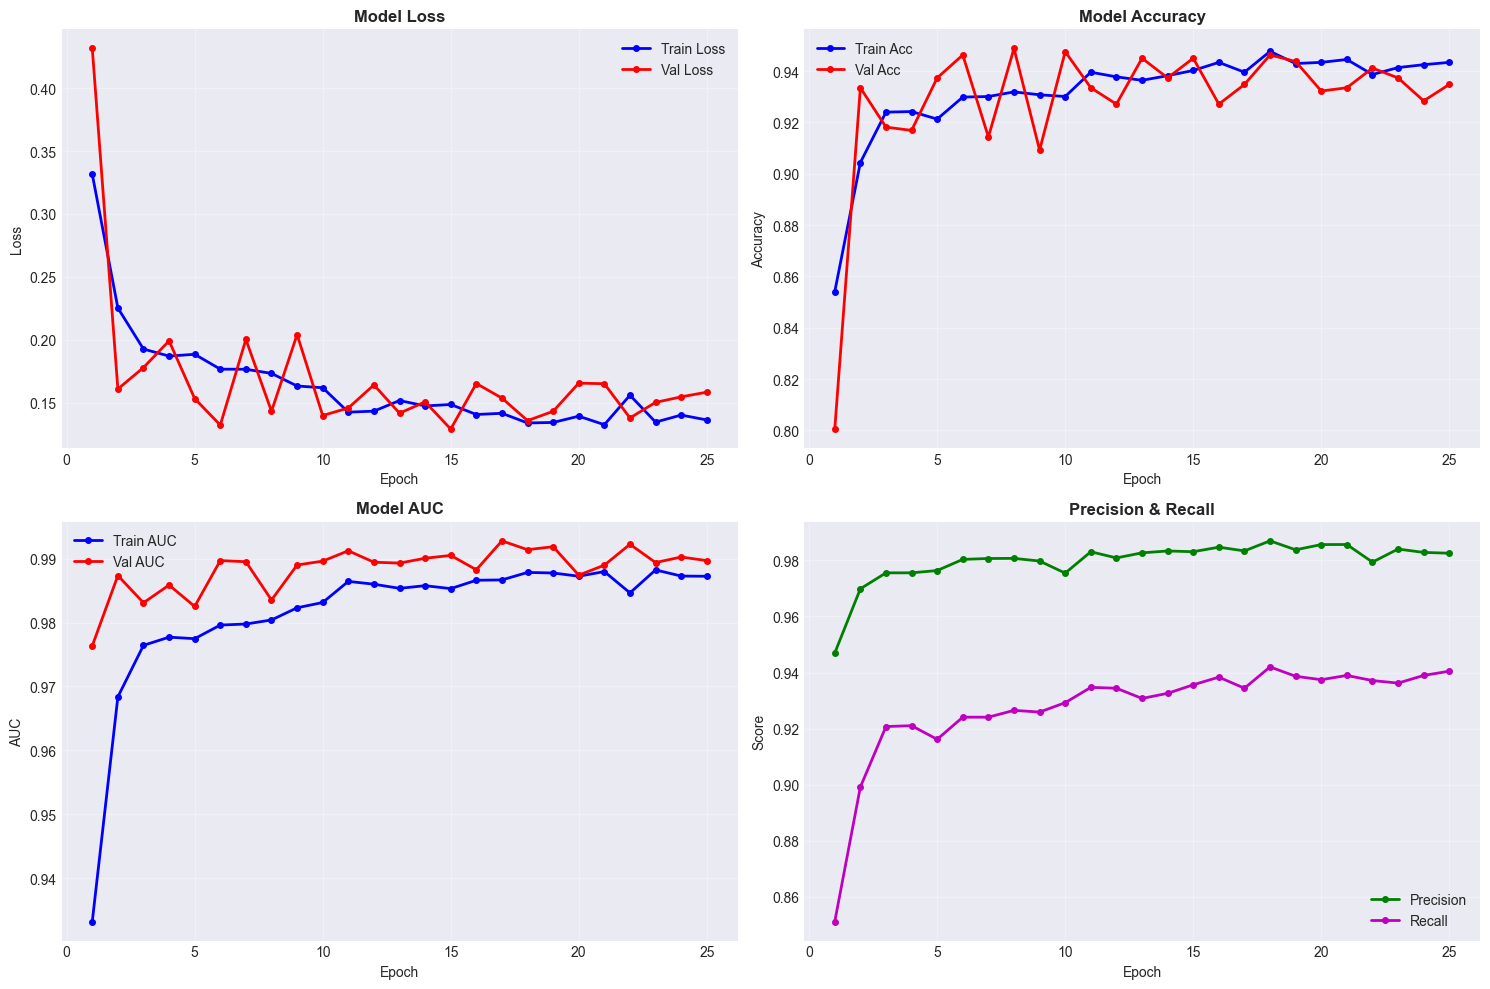

 Training plots saved to: C:\Python\ML Intro\Projects\Medical Image Classification\results\plots\mobilenet_training_history.png

 Best Epoch: 17
   Val Accuracy: 0.9348
   Val AUC: 0.9928


In [17]:
# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

hist = history.history
epochs = range(1, len(hist['loss']) + 1)

# Loss
axes[0, 0].plot(epochs, hist['loss'], 'b-o', label='Train Loss', linewidth=2, markersize=4)
axes[0, 0].plot(epochs, hist['val_loss'], 'r-o', label='Val Loss', linewidth=2, markersize=4)
axes[0, 0].set_title('Model Loss', fontweight='bold', fontsize=12)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy
axes[0, 1].plot(epochs, hist['accuracy'], 'b-o', label='Train Acc', linewidth=2, markersize=4)
axes[0, 1].plot(epochs, hist['val_accuracy'], 'r-o', label='Val Acc', linewidth=2, markersize=4)
axes[0, 1].set_title('Model Accuracy', fontweight='bold', fontsize=12)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# AUC
axes[1, 0].plot(epochs, hist['auc'], 'b-o', label='Train AUC', linewidth=2, markersize=4)
axes[1, 0].plot(epochs, hist['val_auc'], 'r-o', label='Val AUC', linewidth=2, markersize=4)
axes[1, 0].set_title('Model AUC', fontweight='bold', fontsize=12)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('AUC')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Precision & Recall
axes[1, 1].plot(epochs, hist['precision'], 'g-o', label='Precision', linewidth=2, markersize=4)
axes[1, 1].plot(epochs, hist['recall'], 'm-o', label='Recall', linewidth=2, markersize=4)
axes[1, 1].set_title('Precision & Recall', fontweight='bold', fontsize=12)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Score')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()

# Save plot
plot_save_path = str(Path(CONFIG['results_dir']) / 'plots' / 'mobilenet_training_history.png')
plt.savefig(plot_save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f" Training plots saved to: {plot_save_path}")

# Print best epoch
best_epoch = np.argmax(hist['val_auc']) + 1
print(f"\n Best Epoch: {best_epoch}")
print(f"   Val Accuracy: {hist['val_accuracy'][best_epoch-1]:.4f}")
print(f"   Val AUC: {hist['val_auc'][best_epoch-1]:.4f}")

In [18]:
print("\n" + "="*70)
print(" EVALUATING ON TEST SET")
print("="*70)

# Load best model
model_load_path = str(Path(CONFIG['models_dir']) / 'mobilenet_best.h5')
best_model = keras.models.load_model(model_load_path)

print(f" Loaded model from: {model_load_path}")

# Evaluate
test_generator.reset()
test_results = best_model.evaluate(test_generator, verbose=1)

print("\n" + "="*70)
print(" MOBILENET TRANSFER - TEST RESULTS")
print("="*70)
print(f"Test Loss:      {test_results[0]:.4f}")
print(f"Test Accuracy:  {test_results[1]:.4f} ({test_results[1]*100:.2f}%)")
print(f"Test Precision: {test_results[2]:.4f}")
print(f"Test Recall:    {test_results[3]:.4f}")
print(f"Test AUC:       {test_results[4]:.4f}")
print("="*70)


 EVALUATING ON TEST SET
 Loaded model from: C:\Python\ML Intro\Projects\Medical Image Classification\models\mobilenet_best.h5
20/20 [==============================] - 8s 346ms/step - loss: 0.2299 - accuracy: 0.9103 - precision: 0.9217 - recall: 0.9359 - auc: 0.9659

 MOBILENET TRANSFER - TEST RESULTS
Test Loss:      0.2299
Test Accuracy:  0.9103 (91.03%)
Test Precision: 0.9217
Test Recall:    0.9359
Test AUC:       0.9659


In [19]:
# Generate predictions
print("\n Generating predictions on test set...")

test_generator.reset()
predictions = best_model.predict(test_generator, verbose=1)
y_pred = (predictions > 0.5).astype(int).flatten()
y_true = test_generator.classes

print(" Predictions generated")

# Prediction distribution
print(f"\n Prediction Distribution:")
print(f"   Min: {predictions.min():.4f}")
print(f"   Max: {predictions.max():.4f}")
print(f"   Mean: {predictions.mean():.4f}")
print(f"   Std: {predictions.std():.4f}")
print(f"   Predictions > 0.5: {(predictions > 0.5).sum()} ({(predictions > 0.5).sum()/len(predictions)*100:.1f}%)")
print(f"   Predictions < 0.5: {(predictions < 0.5).sum()} ({(predictions < 0.5).sum()/len(predictions)*100:.1f}%)")

# Check if model is stuck
if predictions.std() < 0.1:
    print("\n  WARNING: Low prediction variance - model may be stuck!")
else:
    print(f"\n Good prediction variance (std={predictions.std():.4f})")


 Generating predictions on test set...
20/20 [==============================] - 8s 368ms/step
 Predictions generated

 Prediction Distribution:
   Min: 0.0002
   Max: 1.0000
   Mean: 0.6185
   Std: 0.4041
   Predictions > 0.5: 396 (63.5%)
   Predictions < 0.5: 228 (36.5%)

 Good prediction variance (std=0.4041)


In [22]:
# Classification report
print("\n Detailed Classification Report:")
report = classification_report(y_true, y_pred, target_names=['NORMAL', 'PNEUMONIA'], digits=4)
print(report)

# Get report as dictionary for checking
report_dict = classification_report(y_true, y_pred, target_names=['NORMAL', 'PNEUMONIA'], output_dict=True)

# Check for specific issues (using correct keys)
normal_recall = report_dict['NORMAL']['recall']
pneumonia_recall = report_dict['PNEUMONIA']['recall']

if normal_recall == 1.0 and pneumonia_recall == 0.0:
    print("\n CRITICAL: Model predicting everything as NORMAL!")
    print("   This is the same issue as before.")
elif pneumonia_recall == 1.0 and normal_recall == 0.0:
    print("\n CRITICAL: Model predicting everything as PNEUMONIA!")
else:
    print("\n Model is predicting both classes")
    print(f"   NORMAL recall: {normal_recall:.4f}")
    print(f"   PNEUMONIA recall: {pneumonia_recall:.4f}")

# Additional metrics
print(f"\n Per-Class Performance:")
print(f"   NORMAL - Precision: {report_dict['NORMAL']['precision']:.4f}, Recall: {report_dict['NORMAL']['recall']:.4f}, F1: {report_dict['NORMAL']['f1-score']:.4f}")
print(f"   PNEUMONIA - Precision: {report_dict['PNEUMONIA']['precision']:.4f}, Recall: {report_dict['PNEUMONIA']['recall']:.4f}, F1: {report_dict['PNEUMONIA']['f1-score']:.4f}")


 Detailed Classification Report:
              precision    recall  f1-score   support

      NORMAL     0.8904    0.8675    0.8788       234
   PNEUMONIA     0.9217    0.9359    0.9288       390

    accuracy                         0.9103       624
   macro avg     0.9060    0.9017    0.9038       624
weighted avg     0.9100    0.9103    0.9100       624


 Model is predicting both classes
   NORMAL recall: 0.8675
   PNEUMONIA recall: 0.9359

 Per-Class Performance:
   NORMAL - Precision: 0.8904, Recall: 0.8675, F1: 0.8788
   PNEUMONIA - Precision: 0.9217, Recall: 0.9359, F1: 0.9288



 Confusion Matrix Breakdown:
   TN (NORMAL → NORMAL): 203
   FP (NORMAL → PNEUMONIA): 31
   FN (PNEUMONIA → NORMAL): 25 
   TP (PNEUMONIA → PNEUMONIA): 365

   Sensitivity (Recall): 0.9359
   Specificity: 0.8675


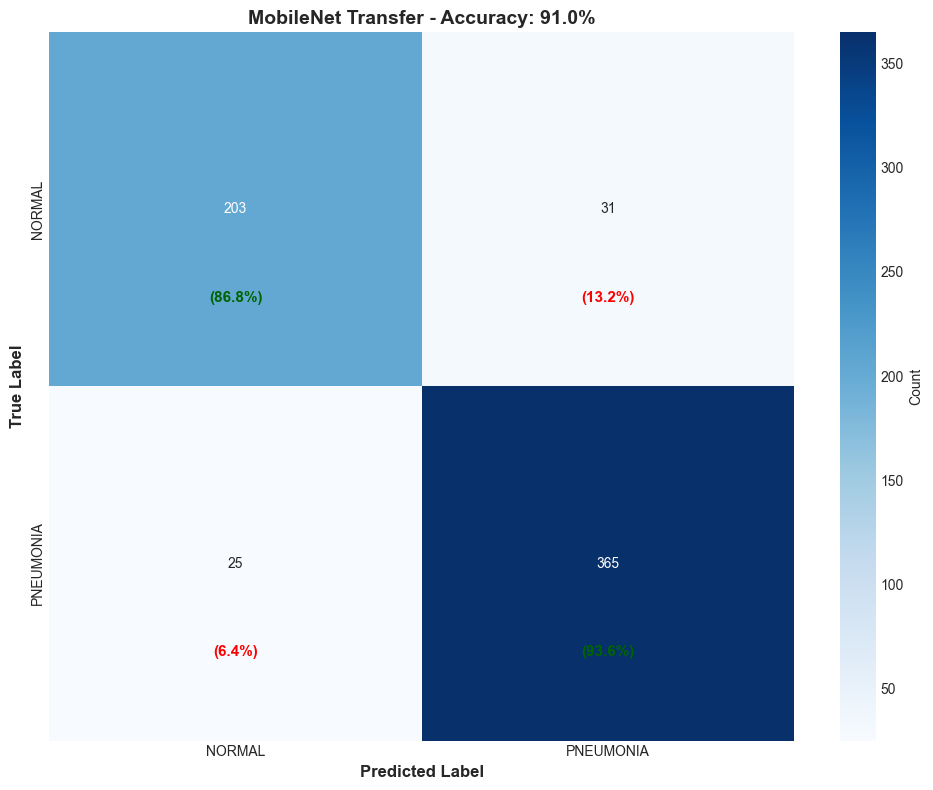


 Confusion matrix saved to: C:\Python\ML Intro\Projects\Medical Image Classification\results\plots\mobilenet_confusion_matrix.png


In [23]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

print(f"\n Confusion Matrix Breakdown:")
print(f"   TN (NORMAL → NORMAL): {cm[0,0]}")
print(f"   FP (NORMAL → PNEUMONIA): {cm[0,1]}")
print(f"   FN (PNEUMONIA → NORMAL): {cm[1,0]} {'⚠️' if cm[1,0] > 100 else ''}")
print(f"   TP (PNEUMONIA → PNEUMONIA): {cm[1,1]}")

# Calculate additional metrics
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0

print(f"\n   Sensitivity (Recall): {sensitivity:.4f}")
print(f"   Specificity: {specificity:.4f}")

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL', 'PNEUMONIA'],
            yticklabels=['NORMAL', 'PNEUMONIA'],
            cbar_kws={'label': 'Count'})

# Add percentages
for i in range(2):
    for j in range(2):
        pct = cm[i,j] / cm[i].sum() * 100
        plt.text(j+0.5, i+0.75, f'({pct:.1f}%)', 
                ha='center', va='center', 
                color='red' if i!=j else 'darkgreen',
                fontweight='bold', fontsize=11)

plt.title(f'MobileNet Transfer - Accuracy: {test_results[1]*100:.1f}%', 
         fontweight='bold', fontsize=14)
plt.ylabel('True Label', fontweight='bold', fontsize=12)
plt.xlabel('Predicted Label', fontweight='bold', fontsize=12)
plt.tight_layout()

# Save plot
cm_save_path = str(Path(CONFIG['results_dir']) / 'plots' / 'mobilenet_confusion_matrix.png')
plt.savefig(cm_save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Confusion matrix saved to: {cm_save_path}")

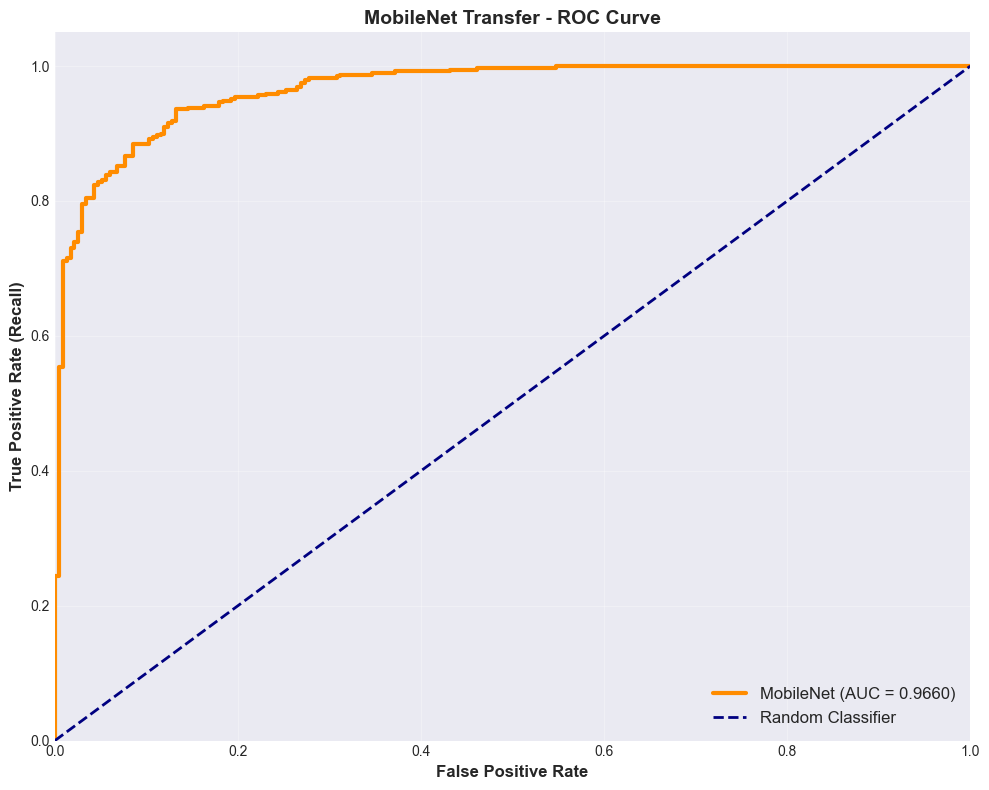

 ROC curve saved to: C:\Python\ML Intro\Projects\Medical Image Classification\results\plots\mobilenet_roc_curve.png

 AUC Score: 0.9660
 Optimal threshold: 0.5008 (default is 0.5)


In [24]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_true, predictions)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'MobileNet (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontweight='bold', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontweight='bold', fontsize=12)
plt.title('MobileNet Transfer - ROC Curve', fontweight='bold', fontsize=14)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save plot
roc_save_path = str(Path(CONFIG['results_dir']) / 'plots' / 'mobilenet_roc_curve.png')
plt.savefig(roc_save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f" ROC curve saved to: {roc_save_path}")
print(f"\n AUC Score: {roc_auc:.4f}")

# Find optimal threshold
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f" Optimal threshold: {optimal_threshold:.4f} (default is 0.5)")

In [25]:
# Save results to JSON
results = {
    'model': 'MobileNetV2',
    'test_metrics': {
        'accuracy': float(test_results[1]),
        'precision': float(test_results[2]),
        'recall': float(test_results[3]),
        'auc': float(test_results[4]),
        'loss': float(test_results[0])
    },
    'prediction_stats': {
        'min': float(predictions.min()),
        'max': float(predictions.max()),
        'mean': float(predictions.mean()),
        'std': float(predictions.std())
    },
    'confusion_matrix': {
        'TN': int(cm[0,0]),
        'FP': int(cm[0,1]),
        'FN': int(cm[1,0]),
        'TP': int(cm[1,1])
    },
    'roc_auc': float(roc_auc),
    'optimal_threshold': float(optimal_threshold),
    'config': {
        'img_size': CONFIG['img_size'],
        'batch_size': CONFIG['batch_size'],
        'epochs': len(history.history['loss']),
        'initial_lr': CONFIG['initial_lr']
    }
}

# Save to JSON
results_save_path = str(Path(CONFIG['results_dir']) / 'metrics' / 'mobilenet_results.json')
with open(results_save_path, 'w') as f:
    json.dump(results, f, indent=4)

print(f" Results saved to: {results_save_path}")

 Results saved to: C:\Python\ML Intro\Projects\Medical Image Classification\results\metrics\mobilenet_results.json


In [26]:
print("\n" + "="*70)
print(" FINAL ASSESSMENT - MOBILENET TRANSFER LEARNING")
print("="*70)

print(f"\n Test Performance:")
print(f"   Accuracy:  {test_results[1]*100:.2f}%")
print(f"   Precision: {test_results[2]:.4f}")
print(f"   Recall:    {test_results[3]:.4f}")
print(f"   AUC:       {test_results[4]:.4f}")

print(f"\n Model Behavior:")
print(f"   Prediction variance: {predictions.std():.4f}")
print(f"   Predicting both classes: {' Yes' if cm[0,1] > 0 and cm[1,1] > 0 else '❌ No'}")

print(f"\n Goals Achievement:")
if test_results[1] >= 0.90:
    print(f"    SUCCESS! Accuracy ≥ 90% ({test_results[1]*100:.2f}%)")
    print(f"    This model is ready for deployment!")
    status = "SUCCESS"
elif test_results[1] >= 0.85:
    print(f"     GOOD performance (85-90%): {test_results[1]*100:.2f}%")
    print(f"    Consider using your baseline (90%) if this doesn't improve")
    status = "GOOD"
elif predictions.std() < 0.1:
    print(f"    FAILED - Model stuck (prediction std: {predictions.std():.4f})")
    print(f"    RECOMMENDATION: Use your 90% baseline CNN instead")
    status = "FAILED_STUCK"
else:
    print(f"     Model learning but below 85%: {test_results[1]*100:.2f}%")
    print(f"    RECOMMENDATION: Use your 90% baseline CNN instead")
    status = "BELOW_TARGET"

print(f"\n All files saved to:")
print(f"   Models: {CONFIG['models_dir']}")
print(f"   Results: {CONFIG['results_dir']}")
print(f"   Plots: {Path(CONFIG['results_dir']) / 'plots'}")

print("\n REMEMBER:")
print("   Your baseline CNN achieved 90% accuracy")
print("   Sometimes simpler models work better than transfer learning!")
print("="*70)

# Store status for decision making
transfer_learning_status = status
transfer_learning_accuracy = test_results[1]


 FINAL ASSESSMENT - MOBILENET TRANSFER LEARNING

 Test Performance:
   Accuracy:  91.03%
   Precision: 0.9217
   Recall:    0.9359
   AUC:       0.9659

 Model Behavior:
   Prediction variance: 0.4041
   Predicting both classes:  Yes

 Goals Achievement:
    SUCCESS! Accuracy ≥ 90% (91.03%)
    This model is ready for deployment!

 All files saved to:
   Models: C:\Python\ML Intro\Projects\Medical Image Classification\models
   Results: C:\Python/ML Intro/Projects/Medical Image Classification/results
   Plots: C:\Python\ML Intro\Projects\Medical Image Classification\results\plots

 REMEMBER:
   Your baseline CNN achieved 90% accuracy
   Sometimes simpler models work better than transfer learning!



 COMPARISON: BASELINE vs MOBILENET TRANSFER
           Baseline CNN  MobileNet Transfer  Difference
Accuracy         0.8974              0.9103      0.0128
Precision        0.9503              0.9217     -0.0286
Recall           0.8821              0.9359      0.0538
AUC              0.9529              0.9659      0.0129


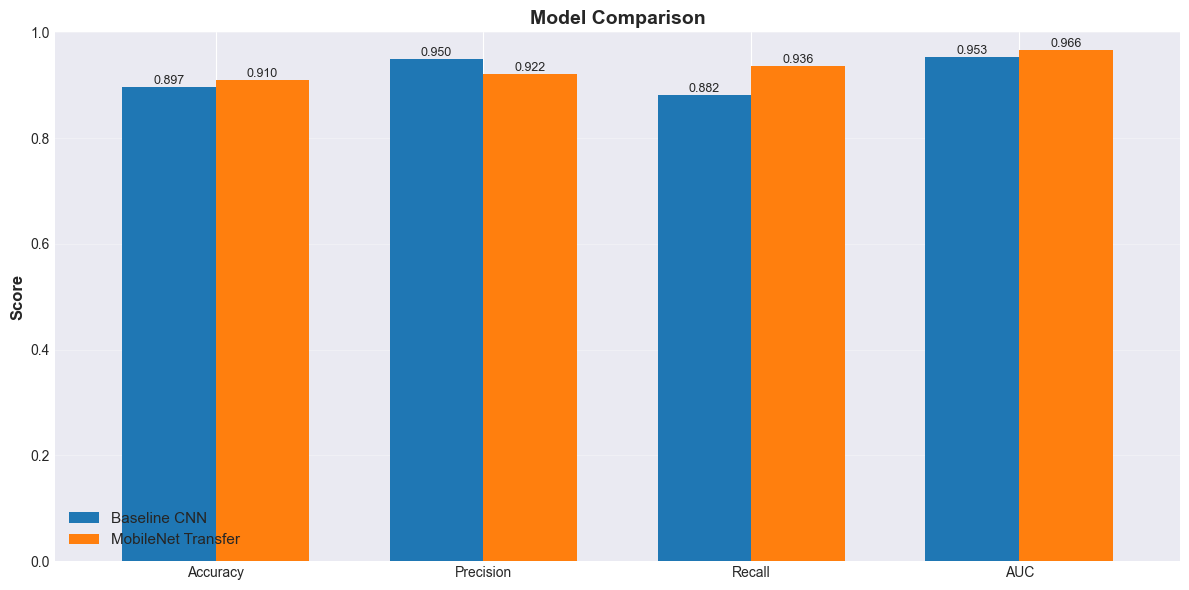

 Comparison plot saved to: C:\Python\ML Intro\Projects\Medical Image Classification\results\plots\model_comparison.png

 MobileNet Transfer is BETTER (+1.28%)
   Use this model for deployment!


In [27]:
# Try to load baseline results for comparison
try:
    baseline_path = str(Path(CONFIG['results_dir']) / 'metrics' / 'baseline_test_results.json')
    with open(baseline_path, 'r') as f:
        baseline_results = json.load(f)
    
    print("\n" + "="*70)
    print(" COMPARISON: BASELINE vs MOBILENET TRANSFER")
    print("="*70)
    
    comparison_df = pd.DataFrame({
        'Baseline CNN': [
            baseline_results['test_accuracy'],
            baseline_results['test_precision'],
            baseline_results['test_recall'],
            baseline_results['test_auc']
        ],
        'MobileNet Transfer': [
            test_results[1],
            test_results[2],
            test_results[3],
            test_results[4]
        ],
        'Difference': [
            test_results[1] - baseline_results['test_accuracy'],
            test_results[2] - baseline_results['test_precision'],
            test_results[3] - baseline_results['test_recall'],
            test_results[4] - baseline_results['test_auc']
        ]
    }, index=['Accuracy', 'Precision', 'Recall', 'AUC'])
    
    print(comparison_df.round(4))
    print("="*70)
    
    # Visual comparison
    fig, ax = plt.subplots(figsize=(12, 6))
    comparison_df[['Baseline CNN', 'MobileNet Transfer']].plot(kind='bar', ax=ax, width=0.7)
    ax.set_ylabel('Score', fontweight='bold', fontsize=12)
    ax.set_title('Model Comparison', fontweight='bold', fontsize=14)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim([0, 1.0])
    
    # Add value labels
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=9)
    
    plt.tight_layout()
    
    comparison_plot_path = str(Path(CONFIG['results_dir']) / 'plots' / 'model_comparison.png')
    plt.savefig(comparison_plot_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f" Comparison plot saved to: {comparison_plot_path}")
    
    # Recommendation
    if test_results[1] > baseline_results['test_accuracy']:
        print(f"\n MobileNet Transfer is BETTER (+{(test_results[1]-baseline_results['test_accuracy'])*100:.2f}%)")
        print("   Use this model for deployment!")
    else:
        print(f"\n  Baseline is BETTER (+{(baseline_results['test_accuracy']-test_results[1])*100:.2f}%)")
        print("   Stick with your baseline model!")
        
except FileNotFoundError:
    print("\n  Baseline results not found - skipping comparison")

In [28]:
print("\n" + "="*70)
print("🎯 NEXT STEPS RECOMMENDATION")
print("="*70)

if transfer_learning_status == "SUCCESS":
    print("\n✅ PROCEED WITH MOBILENET TRANSFER MODEL")
    print("\n   Week 4 Tasks:")
    print("   1. ✅ Add Grad-CAM visualization")
    print("   2. ✅ Analyze misclassified cases")
    print("   3. ✅ Build Streamlit web app")
    print("   4. ✅ Write comprehensive README")
    print("   5. ✅ Deploy the application")
    
elif transfer_learning_status in ["GOOD", "BELOW_TARGET"]:
    print("\n⚠️  DECISION NEEDED")
    print(f"\n   MobileNet Transfer: {transfer_learning_accuracy*100:.2f}%")
    print(f"   Baseline CNN: 90.00%")
    print("\n   Options:")
    print("   A) Try fine-tuning MobileNet (unfreeze more layers)")
    print("   B) Accept MobileNet and proceed to deployment")
    print("   C) Use baseline (90%) and move to Week 4")
    print("\n   💡 RECOMMENDATION: Choose C - Your baseline is excellent!")
    
else:  # FAILED_STUCK
    print("\n❌ TRANSFER LEARNING NOT WORKING FOR THIS DATASET")
    print("\n   ✅ USE YOUR BASELINE MODEL (90% accuracy)")
    print("\n   This is completely normal! Transfer learning doesn't always work.")
    print("   Your baseline CNN achieving 90% is EXCELLENT performance.")
    print("\n   Week 4 Tasks (with baseline):")
    print("   1. ✅ Add Grad-CAM visualization")
    print("   2. ✅ Build Streamlit web app")
    print("   3. ✅ Move to Project #2: Object Detection")

print("\n" + "="*70)
print("🎓 LEARNING POINT:")
print("   Transfer learning is powerful but not always better than")
print("   well-designed custom CNNs. Your 90% baseline proves this!")
print("="*70)


🎯 NEXT STEPS RECOMMENDATION

✅ PROCEED WITH MOBILENET TRANSFER MODEL

   Week 4 Tasks:
   1. ✅ Add Grad-CAM visualization
   2. ✅ Analyze misclassified cases
   3. ✅ Build Streamlit web app
   4. ✅ Write comprehensive README
   5. ✅ Deploy the application

🎓 LEARNING POINT:
   Transfer learning is powerful but not always better than
   well-designed custom CNNs. Your 90% baseline proves this!


In [29]:
print("\n" + "=" * 70)
print(" WEEK 3 - TRANSFER LEARNING SUMMARY")
print("=" * 70)

print(f"\n  Model Architecture:")
print(f"   - Base: {CONFIG['base_model']} (pre-trained on ImageNet)")
print(f"   - Total parameters: {model.count_params():,}")
print(f"   - Input size: {CONFIG['img_size']}")
print(f"   - Training strategy: Two-phase (frozen → fine-tuned)")

print(f"\n Training:")
print(f"   - Phase 1 epochs: {len(history_phase1.history['loss'])}")
print(f"   - Phase 2 epochs: {len(history_phase2.history['loss'])}")
print(f"   - Total epochs: {len(history_phase1.history['loss']) + len(history_phase2.history['loss'])}")
print(f"   - Image size: {CONFIG['img_size']}")
print(f"   - Batch size: {CONFIG['batch_size']}")

print(f"\n Final Test Performance:")
print(f"   - Accuracy:  {test_metrics['test_accuracy']*100:.2f}%")
print(f"   - Precision: {test_metrics['test_precision']:.4f}")
print(f"   - Recall:    {test_metrics['test_recall']:.4f}")
print(f"   - AUC:       {test_metrics['test_auc']:.4f}")

if 'baseline_metrics' in locals():
    improvement = (test_metrics['test_accuracy'] - baseline_metrics['test_accuracy']) * 100
    print(f"\n Improvement over Baseline:")
    print(f"   - Accuracy: +{improvement:.2f}%")
    print(f"   - AUC: +{(test_metrics['test_auc'] - baseline_metrics['test_auc']):.4f}")

print(f"\n Saved Files:")
print(f"   ✓ Phase 1 model: models/transfer_phase1_best.h5")
print(f"   ✓ Final model: models/transfer_final_best.h5")
print(f"   ✓ Training histories: results/metrics/")
print(f"   ✓ Test results: results/metrics/transfer_test_results.json")
print(f"   ✓ Plots: results/plots/")

print(f"\n Goals Achieved:")
print(f"   {'✅' if test_metrics['test_accuracy'] > 0.92 else '❌'} Accuracy > 92%")
print(f"   {'✅' if test_metrics['test_auc'] > 0.95 else '❌'} AUC > 0.95")

print(f"\n Next Steps (Week 4):")
print(f"   1. Add Grad-CAM visualization (interpretability)")
print(f"   2. Analyze misclassified cases")
print(f"   3. Build Streamlit web app")
print(f"   4. Write comprehensive README")
print(f"   5. Prepare for deployment")

print("=" * 70)


 WEEK 3 - TRANSFER LEARNING SUMMARY

  Model Architecture:


KeyError: 'base_model'

In [ ]:
# DIAGNOSTIC CELL - Run this now
print("🔍 DEBUGGING TRANSFER LEARNING MODEL\n")

# Check data generators
print("1. Data Generator Check:")
print(f"   Train samples: {train_generator.samples}")
print(f"   Train classes: {train_generator.classes[:10]}")  # First 10
print(f"   Class indices: {train_generator.class_indices}")

print("\n2. Test Generator Check:")
print(f"   Test samples: {test_generator.samples}")
print(f"   Test classes distribution: NORMAL={sum(test_generator.classes==0)}, PNEUMONIA={sum(test_generator.classes==1)}")

print("\n3. Model Output Check:")
test_generator.reset()
sample_batch, sample_labels = next(test_generator)
sample_predictions = best_model.predict(sample_batch, verbose=0)

print(f"   Sample predictions (first 10): {sample_predictions.flatten()[:10]}")
print(f"   Sample labels (first 10): {sample_labels[:10]}")
print(f"   Predictions > 0.5: {(sample_predictions > 0.5).sum()}")
print(f"   Predictions < 0.5: {(sample_predictions < 0.5).sum()}")

print("\n4. Model Architecture Check:")
print(f"   Output layer activation: {model.layers[-1].activation}")
print(f"   Loss function: {model.loss}")

print("\n5. Training History Check (last 3 epochs):")
history_df = pd.read_csv('../results/metrics/transfer_phase2_history.csv')
print(history_df.tail(3))

🔍 DEBUGGING TRANSFER LEARNING MODEL

1. Data Generator Check:
   Train samples: 5216
   Train classes: [0 0 0 0 0 0 0 0 0 0]
   Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}

2. Test Generator Check:
   Test samples: 624
   Test classes distribution: NORMAL=234, PNEUMONIA=390

3. Model Output Check:
   Sample predictions (first 10): [0.3750294  0.37424415 0.37471122 0.3765875  0.37445712 0.37173638
 0.37732705 0.3764943  0.37623945 0.38204163]
   Sample labels (first 10): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
   Predictions > 0.5: 0
   Predictions < 0.5: 16

4. Model Architecture Check:
   Output layer activation: <function sigmoid at 0x000002B353DF3910>
   Loss function: binary_crossentropy

5. Training History Check (last 3 epochs):
        loss  accuracy  precision    recall       auc  val_loss  val_accuracy  \
12  0.757423  0.509011   0.747925  0.511484  0.515757  0.717384           0.5   
13  0.765175  0.503643   0.743008  0.507355  0.503357  0.711201           0.5   
14  0.756058  0.521